# 03 Per-Cell Fidelity

Score each same-annotation Control-heldout, LD, and NMDA cell against a same-cell-type Control reference centroid.

This is the interpretable per-cell companion to the pseudobulk similarity analysis.

In [1]:
from pathlib import Path
import sys

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from scipy import sparse
from scipy.stats import rankdata

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
sc.settings.verbosity = 2

cwd = Path.cwd().resolve()
REPO_ROOT = cwd if (cwd / "config" / "config.yaml").exists() else cwd.parent
sys.path.insert(0, str(REPO_ROOT / "scripts"))

from fidelity_utils import (
    ensure_output_dirs,
    finite_similarity,
    get_expression_source,
    load_config,
    mean_expression_by_mask,
    normalize_labels,
    resolve_metadata_columns,
    retinal_cell_type_mask,
)

print("Repo root:", REPO_ROOT)
print("scanpy", sc.__version__)
print("anndata", ad.__version__)

Repo root: /Users/louis/Desktop/lab/code/zebrafish-retina-similarity-analysis
scanpy 1.9.3
anndata 0.8.0


## Load Data

In [2]:
config = load_config(REPO_ROOT / "config" / "config.yaml")
tables_dir, figures_dir = ensure_output_dirs(config)

h5ad_path = Path(config["data"]["h5ad_path"])
if not h5ad_path.is_absolute():
    h5ad_path = REPO_ROOT / h5ad_path

adata = sc.read_h5ad(h5ad_path)
condition_column, cell_type_column = resolve_metadata_columns(adata, config)
expression, var_names, expression_source = get_expression_source(adata, config)

print(adata)
print("condition_column:", condition_column)
print("cell_type_column:", cell_type_column)
print("expression_source:", expression_source)

AnnData object with n_obs × n_vars = 160875 × 24597
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'renamed_samples', 'predicted_doublets', 'leiden', 'celltype'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'celltype_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'renamed_samples_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
condition_column: renamed_samples
cell_type_column: celltype
expression_source: raw.X


In [3]:
obs = adata.obs.copy()
obs["_condition"] = normalize_labels(obs[condition_column])
obs["_cell_type"] = normalize_labels(obs[cell_type_column])

metadata = config["metadata"]
analysis = config["analysis"]
per_cell_cfg = analysis.get("per_cell_fidelity", {})

control_label = metadata.get("control_label", "Control")
injury_labels = metadata.get("injury_labels", ["LD", "NMDA"])
min_cells = int(analysis.get("min_cells_per_group", 30))
random_state = int(analysis.get("random_state", 0))
reference_fraction = float(per_cell_cfg.get("control_reference_fraction", 0.7))

METRICS = per_cell_cfg.get("metrics", ["pearson", "spearman", "cosine"])
GENE_SETS = [
    "hvg_1000",
    "hvg_2000",
    "mean_gt_1p5_1k_2k",
    "mean_gt_1p5_frac_gt_10pct_1k_2k",
]

# Experimental expressed-gene sets:
# - Start from each cell type's Control reference cells.
# - Prefer genes with mean expression > 1.5, optionally requiring expression in >=10% of cells.
# - Keep the set between 1k and 2k genes when enough genes are available.
EXPRESSION_GENE_SET_MIN_MEAN = 1.5
EXPRESSION_GENE_SET_MIN_FRACTION = 0.10
EXPRESSION_GENE_SET_MIN_GENES = 1000
EXPRESSION_GENE_SET_MAX_GENES = 2000

gene_cfg = analysis.get("gene_sets", {})
hvg_flavor = gene_cfg.get("hvg_flavor", "seurat")
min_mean_expression = float(gene_cfg.get("min_mean_expression", 0.0))

retinal_mask = retinal_cell_type_mask(obs, "_cell_type", config)
cell_types = sorted(obs.loc[retinal_mask, "_cell_type"].dropna().unique())
cell_types


['AC', 'BC', 'Cones', 'HC', 'MG', 'MGPC', 'PR precursors', 'RGC', 'Rod']

## Helper Functions

In [4]:
def expressed_gene_mask(matrix, min_mean_expression=0.0):
    if sparse.issparse(matrix):
        means = np.asarray(matrix.mean(axis=0)).ravel()
    else:
        means = np.asarray(matrix).mean(axis=0).ravel()
    return means > min_mean_expression


def mean_and_fraction(matrix):
    if sparse.issparse(matrix):
        means = np.asarray(matrix.mean(axis=0)).ravel()
        fractions = np.asarray((matrix > 0).mean(axis=0)).ravel()
    else:
        values = np.asarray(matrix)
        means = values.mean(axis=0)
        fractions = (values > 0).mean(axis=0)
    return means, fractions


def thresholded_mean_gene_indices(
    matrix,
    min_mean=1.5,
    min_fraction=0.0,
    min_genes=1000,
    max_genes=2000,
):
    means, fractions = mean_and_fraction(matrix)
    fraction_ok = fractions >= min_fraction

    primary = np.where((means > min_mean) & fraction_ok)[0]
    primary = primary[np.argsort(means[primary])[::-1]]
    if primary.size >= min_genes:
        return primary[: min(max_genes, primary.size)]

    # If the strict threshold yields fewer than 1k genes, fill with the next-highest
    # expressed genes that still satisfy the fraction rule. This keeps comparisons
    # against hvg_1000/hvg_2000 numerically stable while preserving the threshold first.
    filler = np.where(fraction_ok)[0]
    filler = filler[np.argsort(means[filler])[::-1]]
    ordered = list(primary)
    seen = set(primary.tolist())
    for idx in filler:
        if int(idx) in seen:
            continue
        ordered.append(int(idx))
        seen.add(int(idx))
        if len(ordered) >= min_genes:
            break
    return np.array(ordered[:max_genes], dtype=int)


def variance_gene_indices(matrix, n_top):
    if sparse.issparse(matrix):
        means = np.asarray(matrix.mean(axis=0)).ravel()
        means_sq = np.asarray(matrix.power(2).mean(axis=0)).ravel()
        variances = means_sq - np.square(means)
    else:
        variances = np.asarray(matrix).var(axis=0)
    n = min(int(n_top), matrix.shape[1])
    return np.argsort(variances)[-n:]


def scanpy_hvg_gene_indices(matrix, n_top, flavor="seurat"):
    n = min(int(n_top), matrix.shape[1])
    if n <= 0:
        return np.array([], dtype=int)
    try:
        hvg_adata = ad.AnnData(X=matrix.copy())
        sc.pp.highly_variable_genes(hvg_adata, n_top_genes=n, flavor=flavor, inplace=True)
        indices = np.where(hvg_adata.var["highly_variable"].to_numpy())[0]
        if indices.size > 0:
            return indices[:n]
    except Exception as exc:
        print(f"Scanpy HVG failed for n_top={n_top}; using variance fallback: {exc}")
    return variance_gene_indices(matrix, n)


def dense_matrix(matrix):
    return matrix.toarray() if sparse.issparse(matrix) else np.asarray(matrix)


def score_matrix_to_centroid(matrix, centroid, metric):
    x = dense_matrix(matrix).astype(float, copy=False)
    y = np.asarray(centroid, dtype=float)
    valid = np.isfinite(y)
    x = x[:, valid]
    y = y[valid]
    if y.size < 2 or np.allclose(y, y[0]):
        return np.full(x.shape[0], np.nan)
    if metric == "cosine":
        denom = np.linalg.norm(x, axis=1) * np.linalg.norm(y)
        scores = np.full(x.shape[0], np.nan)
        ok = denom > 0
        scores[ok] = (x[ok] @ y) / denom[ok]
        return scores
    if metric == "pearson":
        yc = y - y.mean()
        xc = x - x.mean(axis=1, keepdims=True)
        denom = np.linalg.norm(xc, axis=1) * np.linalg.norm(yc)
        scores = np.full(x.shape[0], np.nan)
        ok = denom > 0
        scores[ok] = (xc[ok] @ yc) / denom[ok]
        return scores
    if metric == "spearman":
        yr = rankdata(y)
        return np.array([finite_similarity(rankdata(row), yr, "pearson") for row in x])
    raise ValueError(metric)


def select_gene_sets(control_expression, requested_gene_sets):
    expressed_idx = np.where(expressed_gene_mask(control_expression, min_mean_expression))[0]
    selected = {}
    if "shared_expressed" in requested_gene_sets:
        selected["shared_expressed"] = expressed_idx
    for gene_set in requested_gene_sets:
        if gene_set.startswith("hvg_"):
            n_top = int(gene_set.split("_", 1)[1])
            local_idx = scanpy_hvg_gene_indices(control_expression[:, expressed_idx], n_top, hvg_flavor)
            selected[gene_set] = expressed_idx[local_idx]
    if "mean_gt_1p5_1k_2k" in requested_gene_sets:
        selected["mean_gt_1p5_1k_2k"] = thresholded_mean_gene_indices(
            control_expression,
            min_mean=EXPRESSION_GENE_SET_MIN_MEAN,
            min_fraction=0.0,
            min_genes=EXPRESSION_GENE_SET_MIN_GENES,
            max_genes=EXPRESSION_GENE_SET_MAX_GENES,
        )
    if "mean_gt_1p5_frac_gt_10pct_1k_2k" in requested_gene_sets:
        selected["mean_gt_1p5_frac_gt_10pct_1k_2k"] = thresholded_mean_gene_indices(
            control_expression,
            min_mean=EXPRESSION_GENE_SET_MIN_MEAN,
            min_fraction=EXPRESSION_GENE_SET_MIN_FRACTION,
            min_genes=EXPRESSION_GENE_SET_MIN_GENES,
            max_genes=EXPRESSION_GENE_SET_MAX_GENES,
        )
    return selected


## Compute Per-Cell Fidelity Scores

In [5]:
rng = np.random.default_rng(random_state)
records = []
reference_records = []
gene_set_records = []

for cell_type in cell_types:
    cell_mask = (obs["_cell_type"] == cell_type).to_numpy()
    control_mask = cell_mask & (obs["_condition"] == control_label).to_numpy()
    control_indices = np.where(control_mask)[0]
    if control_indices.size < min_cells:
        print(f"Skipping {cell_type}: only {control_indices.size} Control cells")
        continue

    shuffled = rng.permutation(control_indices)
    n_reference = max(2, int(np.floor(reference_fraction * shuffled.size)))
    n_reference = min(n_reference, shuffled.size - 1)
    reference_indices = shuffled[:n_reference]
    heldout_indices = shuffled[n_reference:]

    reference_mask = np.zeros(adata.n_obs, dtype=bool)
    reference_mask[reference_indices] = True
    control_expression = expression[reference_mask]
    gene_sets = select_gene_sets(control_expression, GENE_SETS)

    reference_records.append(
        {"cell_type": cell_type, "reference_n_cells": len(reference_indices), "heldout_n_cells": len(heldout_indices)}
    )

    for gene_set, gene_idx in gene_sets.items():
        gene_set_records.append(
            {
                "cell_type": cell_type,
                "gene_set": gene_set,
                "n_genes": int(len(gene_idx)),
                "genes": ";".join(map(str, var_names[gene_idx])),
            }
        )
        centroid = mean_expression_by_mask(expression[:, gene_idx], reference_mask)
        score_indices = list(heldout_indices)
        for condition in injury_labels:
            score_indices.extend(np.where(cell_mask & (obs["_condition"] == condition).to_numpy())[0].tolist())
        score_indices = np.array(score_indices, dtype=int)
        score_matrix = expression[score_indices][:, gene_idx]

        for metric in METRICS:
            scores = score_matrix_to_centroid(score_matrix, centroid, metric)
            for idx, score in zip(score_indices, scores):
                condition = obs.iloc[idx]["_condition"]
                records.append(
                    {
                        "cell_id": obs.index[idx],
                        "cell_type": cell_type,
                        "condition": "Control_heldout" if condition == control_label else condition,
                        "original_condition": condition,
                        "metric": metric,
                        "gene_set": gene_set,
                        "n_genes": int(len(gene_idx)),
                        "fidelity_score": score,
                        "reference_n_cells": len(reference_indices),
                        "expression_source": expression_source,
                    }
                )

scores = pd.DataFrame(records)
reference_meta = pd.DataFrame(reference_records)
gene_set_report = pd.DataFrame(gene_set_records).drop_duplicates(subset=["cell_type", "gene_set"])
scores.to_csv(tables_dir / "per_cell_fidelity_scores.csv", index=False)
reference_meta.to_csv(tables_dir / "per_cell_fidelity_reference_metadata.csv", index=False)
gene_set_report.to_csv(tables_dir / "per_cell_fidelity_gene_sets.csv", index=False)
gene_set_report[["cell_type", "gene_set", "n_genes"]].pivot(index="cell_type", columns="gene_set", values="n_genes")


If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    finished (0:00:00)
If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    finished (0:00:00)
If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    finished (0:00:00)
If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    finished (0:00:00)
If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    finished (0:00:00)
If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    finished (0:00:00)
If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    finished (0:00:00)
If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    finished (0:00:00)
If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    finished (0:00:00)


,cell_id,cell_type,condition,original_condition,metric,gene_set,n_genes,fidelity_score,reference_n_cells,expression_source
0,GAGCTGCTCTCTCTTC-1,AC,Control_heldout,Control,pearson,hvg_1000,1000,0.487467,9625,raw.X
1,GGGCCATAGGGATCTG-1,AC,Control_heldout,Control,pearson,hvg_1000,1000,0.394820,9625,raw.X
2,AGCTCAAGTACGACTT-1,AC,Control_heldout,Control,pearson,hvg_1000,1000,0.314063,9625,raw.X
3,TGGCGTGTCCTACGGG-1,AC,Control_heldout,Control,pearson,hvg_1000,1000,0.424829,9625,raw.X
4,TGCGGGTCAATTGGTC-1,AC,Control_heldout,Control,pearson,hvg_1000,1000,0.473454,9625,raw.X


## Summary Tables

In [6]:
summary = (
    scores.groupby(["cell_type", "condition", "metric", "gene_set"], observed=False)
    .agg(
        n_cells=("fidelity_score", "size"),
        mean_fidelity=("fidelity_score", "mean"),
        median_fidelity=("fidelity_score", "median"),
        std_fidelity=("fidelity_score", "std"),
    )
    .reset_index()
)
summary.to_csv(tables_dir / "per_cell_fidelity_summary.csv", index=False)
summary.head(30)

,cell_type,condition,metric,gene_set,n_cells,mean_fidelity,median_fidelity,std_fidelity
0,AC,Control_heldout,cosine,hvg_1000,4126,0.471623,0.470807,0.081727
1,AC,Control_heldout,pearson,hvg_1000,4126,0.414448,0.415726,0.087280
2,AC,Control_heldout,spearman,hvg_1000,4126,0.304582,0.297222,0.059496
3,AC,LD,cosine,hvg_1000,342,0.405099,0.403192,0.057278
4,AC,LD,pearson,hvg_1000,342,0.348489,0.348723,0.062156
5,AC,LD,spearman,hvg_1000,342,0.258579,0.254399,0.044602
6,AC,NMDA,cosine,hvg_1000,1424,0.376258,0.379486,0.074860
7,AC,NMDA,pearson,hvg_1000,1424,0.320663,0.323589,0.076937
8,AC,NMDA,spearman,hvg_1000,1424,0.238712,0.240249,0.050411
9,BC,Control_heldout,cosine,hvg_1000,18866,0.488612,0.485936,0.065711


In [7]:
PLOT_METRIC = per_cell_cfg.get("default_plot_metric", "pearson")
PLOT_GENE_SET = "mean_gt_1p5_frac_gt_10pct_1k_2k"

plot_scores = scores[(scores["metric"] == PLOT_METRIC) & (scores["gene_set"] == PLOT_GENE_SET)].copy()
plot_scores["condition"] = pd.Categorical(plot_scores["condition"], ["Control_heldout", "LD", "NMDA"], ordered=True)
plot_scores.shape


(64612, 10)

## Combined Violin Plot

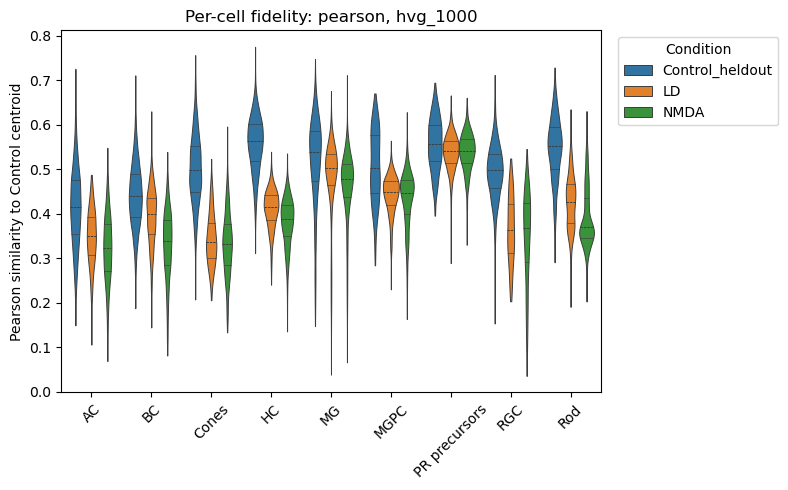

In [8]:
fig, ax = plt.subplots(figsize=(max(8, 0.85 * plot_scores["cell_type"].nunique()), 5))
sns.violinplot(
    data=plot_scores,
    x="cell_type",
    y="fidelity_score",
    hue="condition",
    cut=0,
    inner="quartile",
    linewidth=0.7,
    ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel(f"{PLOT_METRIC.title()} similarity to Control centroid")
ax.set_title(f"Per-cell fidelity: {PLOT_METRIC}, {PLOT_GENE_SET}")
ax.tick_params(axis="x", labelrotation=45)
ax.legend(title="Condition", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(figures_dir / f"per_cell_fidelity_violin_{PLOT_METRIC}_{PLOT_GENE_SET}.png", dpi=300, bbox_inches="tight")

## Cell-Type Facets

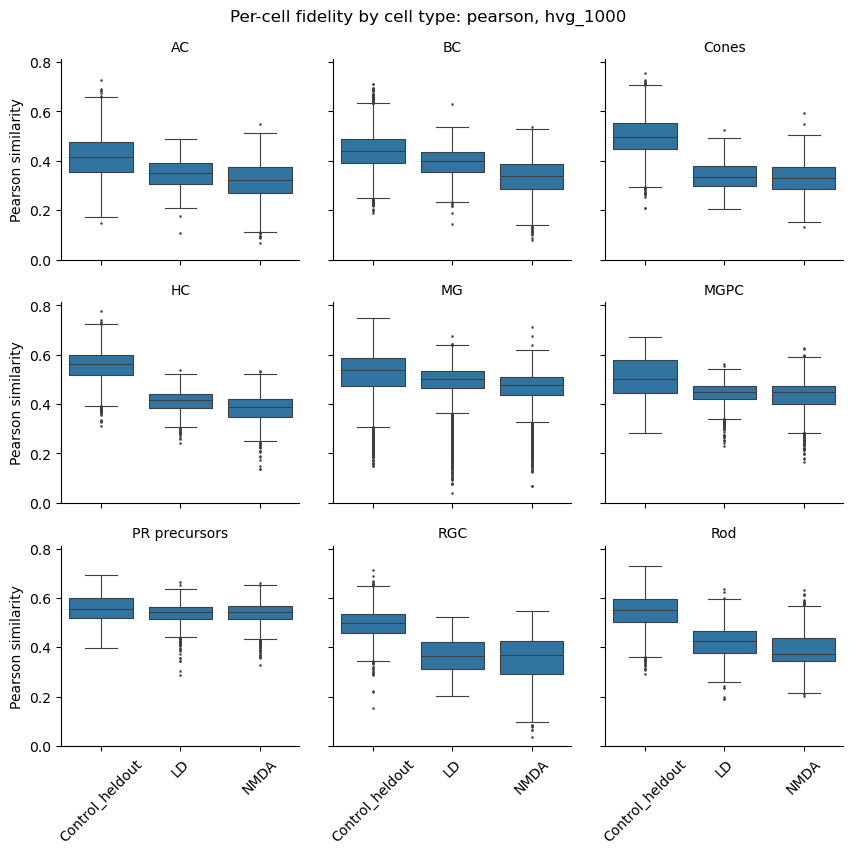

In [9]:
grid = sns.catplot(
    data=plot_scores,
    x="condition",
    y="fidelity_score",
    col="cell_type",
    col_wrap=3,
    kind="box",
    sharey=True,
    height=2.6,
    aspect=1.1,
    fliersize=0.8,
    linewidth=0.8,
)
grid.set_axis_labels("", f"{PLOT_METRIC.title()} similarity")
grid.set_titles("{col_name}")
for ax in grid.axes.flat:
    ax.tick_params(axis="x", labelrotation=45)
grid.fig.suptitle(f"Per-cell fidelity by cell type: {PLOT_METRIC}, {PLOT_GENE_SET}", y=1.02)
grid.fig.savefig(figures_dir / f"per_cell_fidelity_box_by_cell_type_{PLOT_METRIC}_{PLOT_GENE_SET}.png", dpi=300, bbox_inches="tight")

## UMAP Colored By Fidelity Score

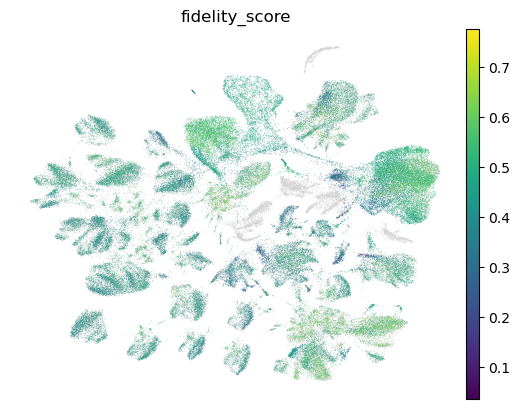

/Users/louis/miniforge3/envs/retina-fidelity/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/Users/louis/miniforge3/envs/retina-fidelity/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


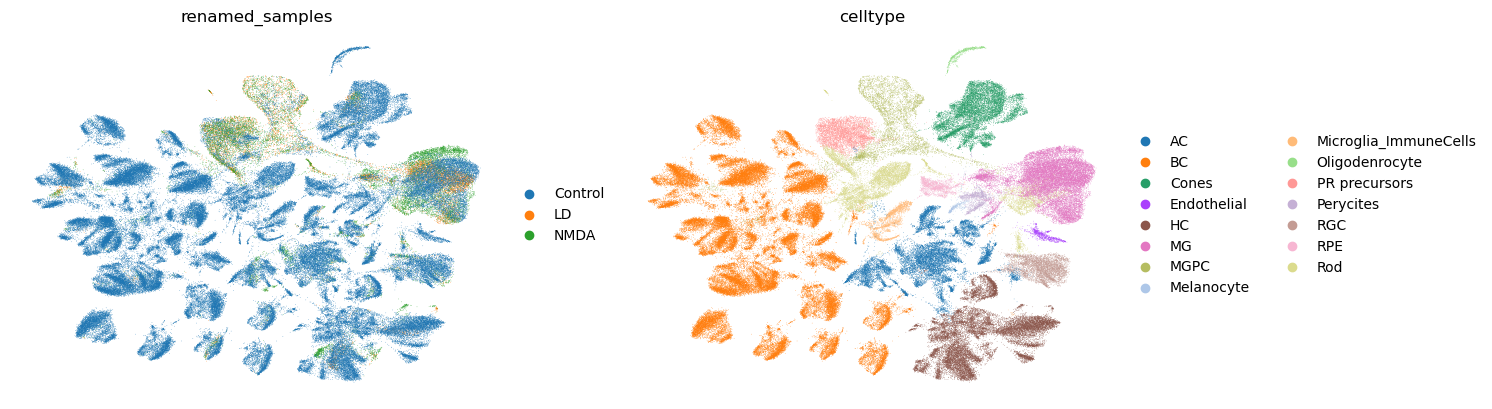

In [10]:
if "X_umap" in adata.obsm:
    score_map = plot_scores.set_index("cell_id")["fidelity_score"]
    adata.obs["fidelity_score"] = adata.obs_names.map(score_map)
    sc.pl.umap(adata, color="fidelity_score", frameon=False, cmap="viridis")
    sc.pl.umap(adata, color=[condition_column, cell_type_column], frameon=False)
else:
    print("No X_umap found.")

## Script Equivalent

```bash
python scripts/per_cell_fidelity.py --config config/config.yaml
```

For a broader run:

```bash
python scripts/per_cell_fidelity.py --config config/config.yaml --gene-sets shared_expressed hvg_1000 hvg_2000
```